# Part 2: Overbooking Optimization (RQ2)

Dynamic overbooking strategy via Discrete Newsvendor Problem.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from utils import load_hotel_data, OUTPUT_DIR

RANDOM_STATE = 316
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
%matplotlib inline

In [25]:
# Load selected-feature metadata saved by Part 1
import json

with open(OUTPUT_DIR / "selected_features_meta.json") as f:
    meta = json.load(f)

selected_ix = meta["selected_ix"]
CANDIDATE_FEATURES = meta["candidate_features"]

In [26]:
# ROOM_REVENUE is the revenue missed due to cancellation
ROOM_REVENUE = 150  

# WALK_COST is the cost of compensation due to overbooking
WALK_COST = 450

Cu = ROOM_REVENUE 
Co = WALK_COST

CRITICAL_RATIO = Cu / (Cu + Co)
print(f"Critical ratio is {CRITICAL_RATIO}")

Critical ratio is 0.25


## Step 1: Load Data and Model from Part 1

Rebuild the predictive cancellation model using the pipeline from Part 1

In [27]:
df_raw = load_hotel_data()

df = df_raw.copy()

df = df.dropna(subset=["children"])
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]

month_map = {
    "January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
    "July":7,"August":8,"September":9,"October":10,"November":11,"December":12
}
df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
df["arrival_date"] = pd.to_datetime(
    df[["arrival_date_year", "arrival_month_num", "arrival_date_day_of_month"]]
    .rename(columns={
        "arrival_date_year": "year",
        "arrival_month_num": "month",
        "arrival_date_day_of_month": "day"
    })
)

print(f"Cleaned data: {df.shape[0]:,} rows")
print(f"Date range: {df['arrival_date'].min().date()} → {df['arrival_date'].max().date()}")

Cleaned data: 119,206 rows
Date range: 2015-07-01 → 2017-08-31


In [28]:
# Load the saved pipeline from Part 1
pipeline = joblib.load(OUTPUT_DIR / "pred_pipeline.joblib")
print(f"Pipeline steps: {[s[0] for s in pipeline.steps]}")

Pipeline steps: ['preprocessor', 'model']


In [29]:
# Sort chronologically and split 80 / 20
df = df.sort_values("arrival_date").reset_index(drop=True)

split_idx  = int(len(df) * 0.80)
split_date = df.iloc[split_idx]["arrival_date"]

df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

print(f"Train: {len(df_train):,} rows\nTest: {len(df_test):,} rows")
print(f"Test period: {df_test['arrival_date'].min().date()} → {df_test['arrival_date'].max().date()}")
print(f"Test dates : {df_test['arrival_date'].nunique():,} unique check-in days")


Train: 95,364 rows
Test: 23,842 rows
Test period: 2017-04-22 → 2017-08-31
Test dates : 132 unique check-in days


In [30]:
# Apply Part 1 pipeline to test-set bookings only
X_test_raw = df_test[CANDIDATE_FEATURES].copy()

TOP_COUNTRY_K = 15
if "country" in X_test_raw.columns:
    top_countries = df_train["country"].value_counts().head(TOP_COUNTRY_K).index.tolist()
    X_test_raw["country"] = X_test_raw["country"].where(
        X_test_raw["country"].isin(top_countries), "Other"
    )

X_test_transformed = pipeline.named_steps["preprocessor"].transform(X_test_raw)
X_test_sel         = X_test_transformed[:, selected_ix]
model              = pipeline.named_steps["model"]

df_test = df_test.copy()
df_test["cancel_prob"] = model.predict_proba(X_test_sel)[:, 1]

print(f"Cancel prob range : [{df_test['cancel_prob'].min():.3f}, {df_test['cancel_prob'].max():.3f}]")
print(f"Mean cancel prob  : {df_test['cancel_prob'].mean():.3f}")
print(f"Actual cancel rate: {df_test['is_canceled'].mean():.3f}")


Cancel prob range : [0.000, 1.000]
Mean cancel prob  : 0.413
Actual cancel rate: 0.410


c:\Users\101jc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Step 2: Build Poisson Binomial Distribution

Model each day's cancellations as a Poisson Binomial over per-booking probabilities and solve for the optimal overbooking quantity via the newsvendor critical ratio.

For a check-in date with $n$ bookings and individual cancel probabilities
$p_1, \ldots, p_n$, the number of cancellations follows a
**Poisson Binomial** distribution:

$$D \sim \text{PoissonBinomial}(p_1, \ldots, p_n)$$

In [31]:
def poisson_binomial_pmf(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    n = len(probs)
    pmf = np.zeros(n + 1)
    pmf[0] = 1.0
    for p in probs:
        # Shift-and-add in reverse to avoid overwriting values we still need
        pmf[1:] = pmf[1:] * (1 - p) + pmf[:-1] * p
        pmf[0] *= (1 - p)
    return pmf


def newsvendor_q(pmf: np.ndarray, critical_ratio: float) -> int:
    cdf = np.cumsum(pmf)
    candidates = np.where(cdf >= critical_ratio)[0]
    return int(candidates[0]) if len(candidates) > 0 else len(pmf) - 1

Example date         : 2017-06-16
Bookings on that day : 184
Expected cancels     : 94.6
Optimal overbook q*  : 92
Actual # of cancels  : 91


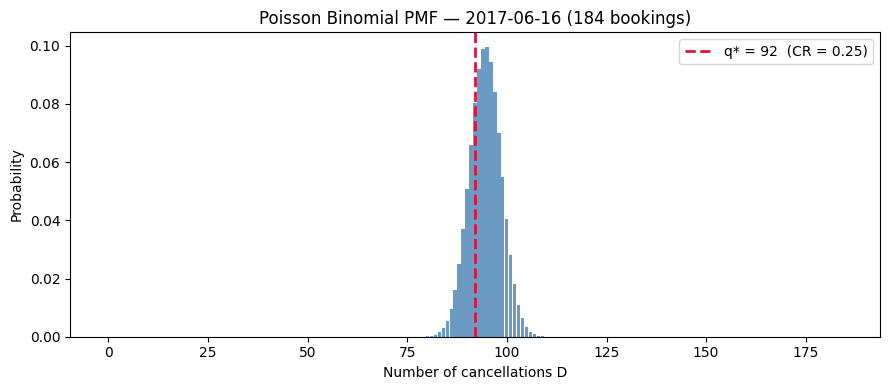

In [32]:
# Output PMF graph of a random date from test-set
example_date  = df_test["arrival_date"].drop_duplicates().sample(1).iloc[0]
example_probs = df_test.loc[df_test["arrival_date"] == example_date, "cancel_prob"].values
example_pmf   = poisson_binomial_pmf(example_probs)
example_q     = newsvendor_q(example_pmf, CRITICAL_RATIO)

print(f"Example date         : {example_date.date()}")
print(f"Bookings on that day : {len(example_probs)}")
print(f"Expected cancels     : {example_probs.sum():.1f}")
print(f"Optimal overbook q*  : {example_q}")
print(f"Actual # of cancels  : {df_test.loc[df_test['arrival_date'] == example_date, 'is_canceled'].sum()}")


fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(example_pmf)), example_pmf, color="steelblue", alpha=0.8)
ax.axvline(example_q, color="crimson", linewidth=2, linestyle="--",
           label=f"q* = {example_q}  (CR = {CRITICAL_RATIO:.2f})")
ax.set_xlabel("Number of cancellations D")
ax.set_ylabel("Probability")
ax.set_title(f"Poisson Binomial PMF — {example_date.date()} ({len(example_probs)} bookings)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "fig_pmf_example.png", dpi=150)
plt.show()

## Step 3: Apply Dynamic Overbooking Policy

**Decision rule:**  
For each check-in date $d$ with bookings $\{1, \ldots, n_d\}$:

$$q^*_d = F_d^{-1}(\text{CR}) = \min\{q : F_d(q) \geq \text{CR}\}$$

where $F_d$ is the CDF of the Poisson Binomial distribution of cancellations on day $d$.

**Profit model** (per day):

- Actual arrivals $= n_d - D_d$ where $D_d$ is realised cancellations.
- We accept up to $n_d + q^*_d$ bookings, so up to $q^*_d$ extra guests may arrive.
- Walks $= \max(0,\ q^*_d - D_d)$
- Empty rooms $= \max(0,\ D_d - q^*_d)$
- $\text{Profit} = r \cdot (n_d - \text{Empty}) - c_{\text{walk}} \cdot \text{Walks}$

In [33]:
def compute_daily_policy(group: pd.DataFrame, critical_ratio: float) -> dict:
    probs = group["cancel_prob"].values
    actual_cancels = int(group["is_canceled"].sum())
    n_bookings = len(probs)

    pmf = poisson_binomial_pmf(probs)
    q_star = newsvendor_q(pmf, critical_ratio)

    exp_cancels = float(probs.sum())

    walks = max(0, q_star - actual_cancels)
    empty_rooms = max(0, actual_cancels - q_star)

    return {
        "n_bookings"    : n_bookings,
        "exp_cancels"   : round(exp_cancels, 2),
        "actual_cancels": actual_cancels,
        "q_star"        : q_star,
        "walks"         : walks,
        "empty_rooms"   : empty_rooms,
    }

In [34]:
# Apply dynamic policy to all test dates
records = []
for date, grp in df_test.groupby("arrival_date"):
    rec = compute_daily_policy(grp, CRITICAL_RATIO)
    rec["arrival_date"] = date
    records.append(rec)

results = pd.DataFrame(records).sort_values("arrival_date").reset_index(drop=True)

# Calculate the extra profit from dynamic policy
results["dynamic_profit"] = (
    ROOM_REVENUE * (results["n_bookings"] - results["empty_rooms"])
    - WALK_COST  *  results["walks"]
)

## Step 4: Compute Static Baseline

Derive a fixed overbooking quantity from the training-period average daily cancellations as a naive comparison benchmark.


The static baseline overbooks by a **fixed quantity** derived from the historical
average cancellation rate on the *training* portion of the data.

$$q_{\text{static}} = \text{round}\left(\bar{n}_{\text{train}} \times \bar{p}_{\text{train}}\right)$$

In [35]:
train_daily = df_train.groupby("arrival_date").agg(
    n_bookings=("is_canceled", "count"),
    n_cancels =("is_canceled", "sum"),
).reset_index()

static_q = int(round(train_daily["n_cancels"].mean()))
avg_cancel_rate = df_train["is_canceled"].mean()

print(f"Training cancel rate     : {avg_cancel_rate:.3f}")
print(f"Avg daily cancellations  : {train_daily['n_cancels'].mean():.2f}")
print(f"Static overbooking q     : {static_q}")


Training cancel rate     : 0.361
Avg daily cancellations  : 52.00
Static overbooking q     : 52


In [36]:
# Apply static policy to all test dates
results["static_q"]     = static_q
results["static_walks"] = (results["static_q"] - results["actual_cancels"]).clip(lower=0)
results["static_empty"] = (results["actual_cancels"] - results["static_q"]).clip(lower=0)

# Calculate the extra profit from static policy
results["static_profit"] = (
    ROOM_REVENUE * (results["n_bookings"] - results["static_empty"])
    - WALK_COST  *  results["static_walks"]
)

## Step 5: Dynamic vs. Static Evaluation

Compare the dynamic newsvendor policy against the static baseline.

In [37]:
# Policy comparison summary
profit_diff     = results["dynamic_profit"].sum() - results["static_profit"].sum()
profit_diff_pct = profit_diff / abs(results["static_profit"].sum()) * 100

comparison = pd.DataFrame({
    "Metric": [
        "Total days",
        "Total bookings",
        "Avg overbooking q per day",
        "Total walks",
        "Days with walks (%)",
        "Total empty rooms",
        "Days with empties (%)",
        "Total profit ($)",
        "Avg daily profit ($)",
        "Profit improvement vs static ($)",
        "Profit improvement vs static (%)",
    ],
    "Dynamic": [
        f"{len(results)}",
        f"{results['n_bookings'].sum():,}",
        f"{results['q_star'].mean():.2f}",
        f"{results['walks'].sum():,}",
        f"{(results['walks'] > 0).mean()*100:.1f}",
        f"{results['empty_rooms'].sum():,}",
        f"{(results['empty_rooms'] > 0).mean()*100:.1f}",
        f"{results['dynamic_profit'].sum():,.0f}",
        f"{results['dynamic_profit'].mean():,.2f}",
        f"+{profit_diff:,.2f}",
        f"{profit_diff_pct:+.2f}",
    ],
    "Static": [
        f"{len(results)}",
        f"{results['n_bookings'].sum():,}",
        f"{static_q:.2f}",
        f"{results['static_walks'].sum():,}",
        f"{(results['static_walks'] > 0).mean()*100:.1f}",
        f"{results['static_empty'].sum():,}",
        f"{(results['static_empty'] > 0).mean()*100:.1f}",
        f"{results['static_profit'].sum():,.0f}",
        f"{results['static_profit'].mean():,.2f}",
        "—",
        "—",
    ],
})

print(comparison.to_string(index=False))

                          Metric     Dynamic    Static
                      Total days         132       132
                  Total bookings      23,842    23,842
       Avg overbooking q per day       71.90     52.00
                     Total walks          40       322
             Days with walks (%)        15.9      26.5
               Total empty rooms         322     3,231
           Days with empties (%)        73.5      72.7
                Total profit ($)   3,510,000 2,946,750
            Avg daily profit ($)   26,590.91 22,323.86
Profit improvement vs static ($) +563,250.00         —
Profit improvement vs static (%)      +19.11         —


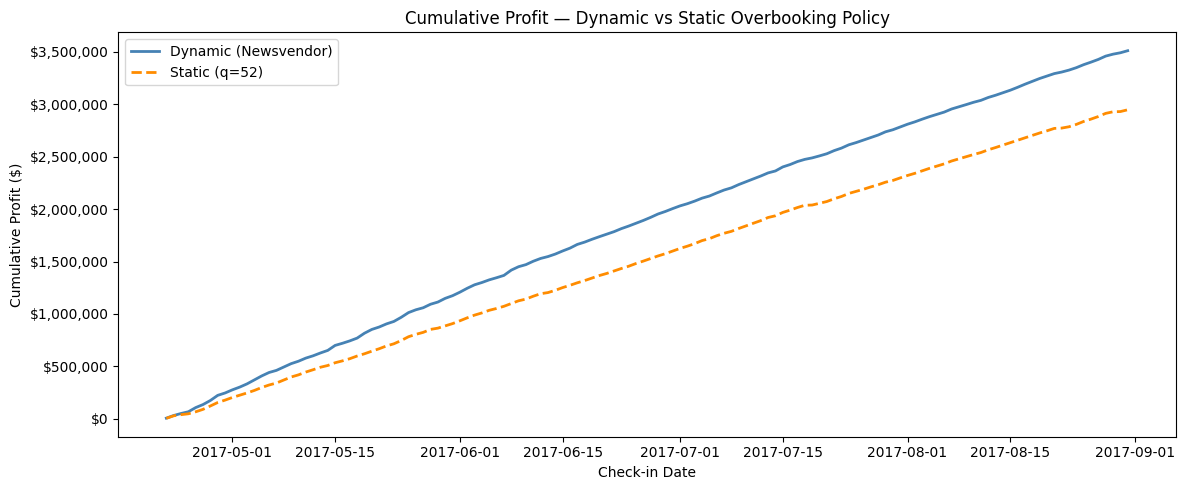

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(results["arrival_date"], results["dynamic_profit"].cumsum(),
        label="Dynamic (Newsvendor)", color="steelblue", linewidth=2)
ax.plot(results["arrival_date"], results["static_profit"].cumsum(),
        label=f"Static (q={static_q})", color="darkorange", linewidth=2, linestyle="--")

ax.set_xlabel("Check-in Date")
ax.set_ylabel("Cumulative Profit ($)")
ax.set_title("Cumulative Profit — Dynamic vs Static Overbooking Policy")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR  / "figures" / "fig_cumulative_profit.png", dpi=150)
plt.show()

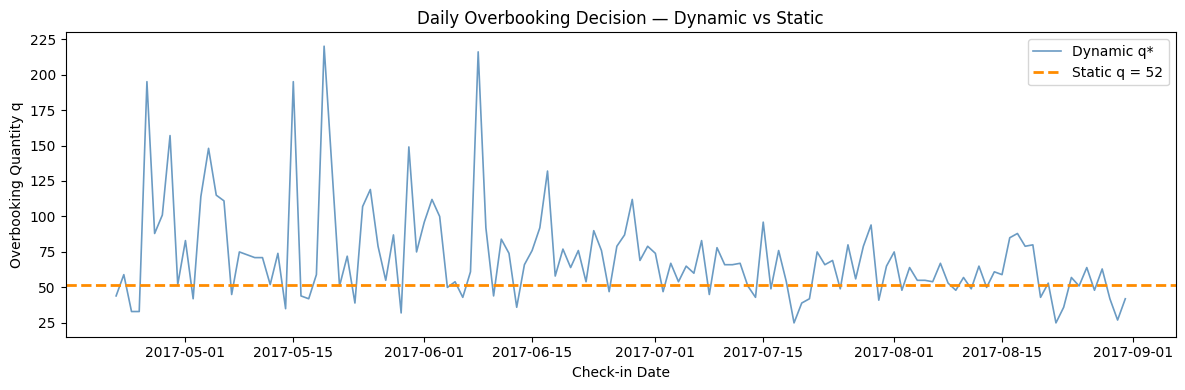

In [39]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(results["arrival_date"], results["q_star"],
        label="Dynamic q*", color="steelblue", alpha=0.8, linewidth=1.2)
ax.axhline(static_q, color="darkorange", linewidth=2, linestyle="--",
           label=f"Static q = {static_q}")

ax.set_xlabel("Check-in Date")
ax.set_ylabel("Overbooking Quantity q")
ax.set_title("Daily Overbooking Decision — Dynamic vs Static")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR  / "figures" / "fig_daily_q.png", dpi=150)
plt.show()

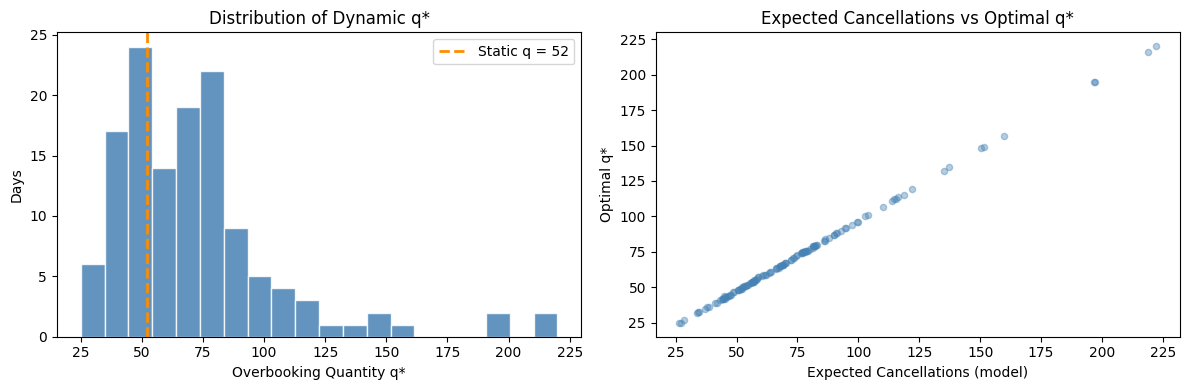

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results["q_star"], bins=20, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(static_q, color="darkorange", linewidth=2, linestyle="--",
                label=f"Static q = {static_q}")
axes[0].set_xlabel("Overbooking Quantity q*")
axes[0].set_ylabel("Days")
axes[0].set_title("Distribution of Dynamic q*")
axes[0].legend()

axes[1].scatter(results["exp_cancels"], results["q_star"],
                alpha=0.4, s=20, color="steelblue")
axes[1].set_xlabel("Expected Cancellations (model)")
axes[1].set_ylabel("Optimal q*")
axes[1].set_title("Expected Cancellations vs Optimal q*")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "fig_q_distribution.png", dpi=150)
plt.show()

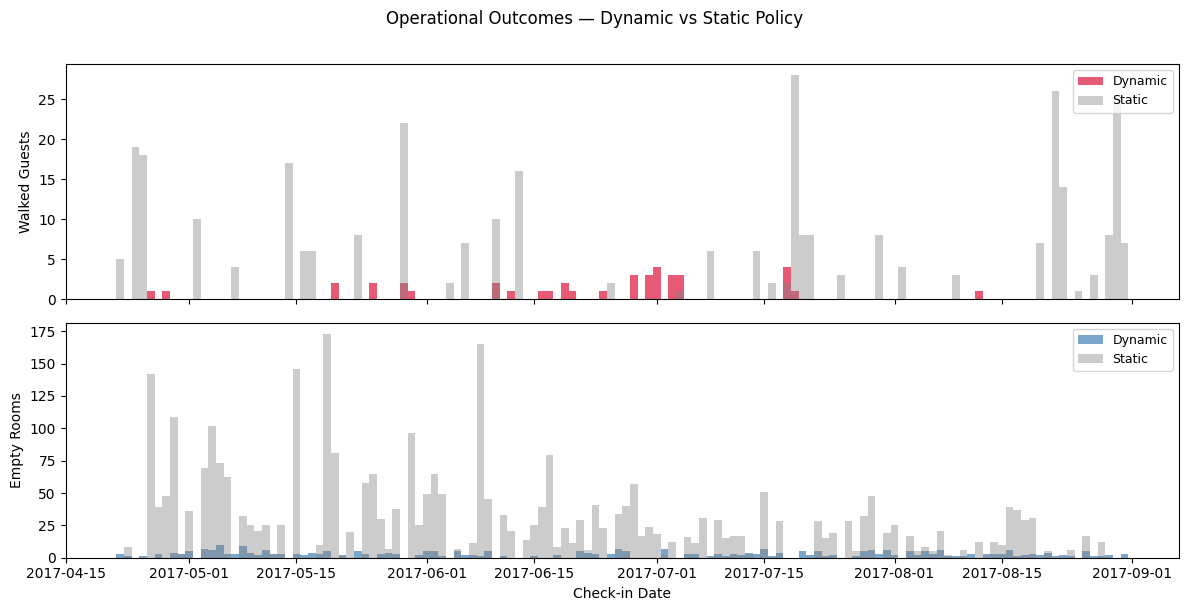

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, col_d, col_s, label, color in zip(
    axes,
    ["walks",         "empty_rooms"],
    ["static_walks",  "static_empty"],
    ["Walked Guests", "Empty Rooms"],
    ["crimson",       "steelblue"],
):
    ax.bar(results["arrival_date"], results[col_d],
           label="Dynamic", alpha=0.7, color=color, width=1)
    ax.bar(results["arrival_date"], results[col_s],
           label="Static", alpha=0.4, color="grey", width=1)
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=9)

axes[1].set_xlabel("Check-in Date")
fig.suptitle("Operational Outcomes — Dynamic vs Static Policy", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figures" / "fig_walks_and_empties.png", dpi=150)
plt.show()